# Proiect 2- Regresie Liniara -  Iliescu Daria

In [64]:
#1
# Importarea bibliotecilor
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [65]:
vietnam_df=pd.read_csv("vietnam_housing_dataset.csv")


In [66]:
vietnam_df.head()

,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


In [67]:
print("===== Rezumat DataFrame =====")
vietnam_df.info()

===== Rezumat DataFrame =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            30229 non-null  object 
 1   Area               30229 non-null  float64
 2   Frontage           18665 non-null  float64
 3   Access Road        16932 non-null  float64
 4   House direction    8990 non-null   object 
 5   Balcony direction  5246 non-null   object 
 6   Floors             26626 non-null  float64
 7   Bedrooms           25067 non-null  float64
 8   Bathrooms          23155 non-null  float64
 9   Legal status       25723 non-null  object 
 10  Furniture state    16110 non-null  object 
 11  Price              30229 non-null  float64
dtypes: float64(7), object(5)
memory usage: 2.8+ MB


In [68]:
print("===== Număr de valori unice per coloană =====")
vietnam_df.nunique()

===== Număr de valori unice per coloană =====


Address              10265
Area                  1512
Frontage               407
Access Road            140
House direction          8
Balcony direction        8
Floors                  10
Bedrooms                 9
Bathrooms                9
Legal status             2
Furniture state          2
Price                  687
dtype: int64

In [69]:
# Verificarea valorilor lipsă 
missing_values =vietnam_df.isna().sum()
if missing_values.sum() > 0:
    print("Valori lipsă pe coloană:")
    print(missing_values[missing_values > 0])
else:
    print("Nu există valori lipsă în setul de date.")

Valori lipsă pe coloană:
Frontage             11564
Access Road          13297
House direction      21239
Balcony direction    24983
Floors                3603
Bedrooms              5162
Bathrooms             7074
Legal status          4506
Furniture state      14119
dtype: int64


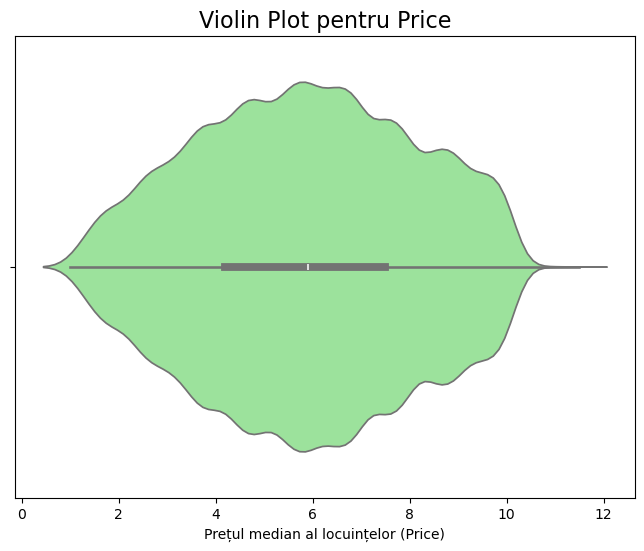

In [70]:
# Creare violin plot pentru MEDV
plt.figure(figsize=(8,6))
sns.violinplot(x=vietnam_df['Price'], color='lightgreen')

# Adăugare titlu și etichetă pe axa x
plt.title("Violin Plot pentru Price", fontsize=16)
plt.xlabel("Prețul median al locuințelor (Price)")

plt.show()

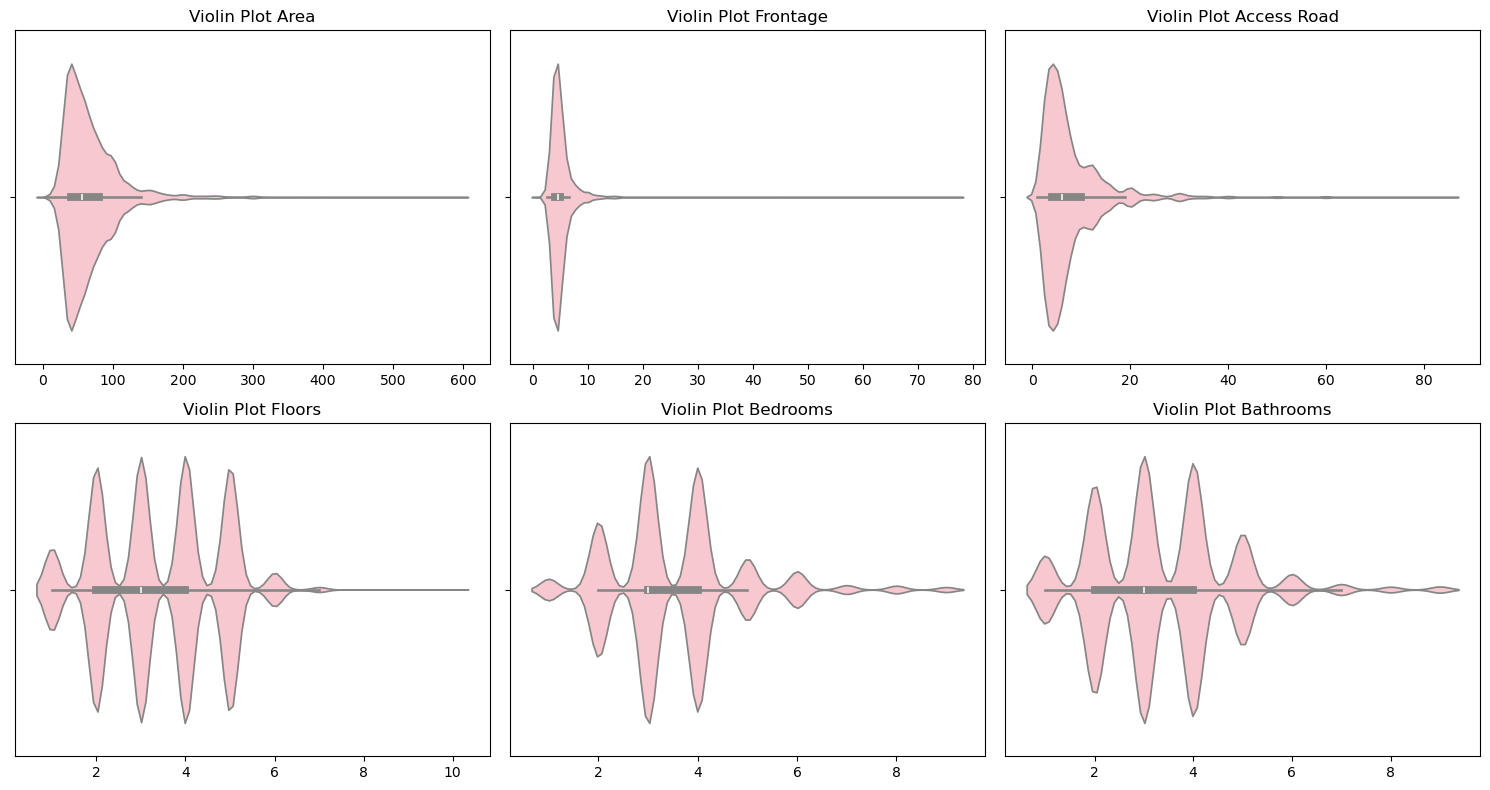

In [71]:
# Selectare coloanele numerice
vietnam_df_plot=vietnam_df.drop('Price', axis=1)
num_cols = vietnam_df_plot.select_dtypes(include=[np.number]).columns

# Setare subploturi
n_cols = 3  # număr de coloane în figură
n_rows = int(np.ceil(len(num_cols) / n_cols))  # calculăm rândurile necesare
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten()  # flatten pentru iterație ușoară

# Creare violin plot pentru fiecare coloană numerică
for i, col in enumerate(num_cols):
    sns.violinplot(x=vietnam_df_plot[col], ax=axes[i], color='pink')
    axes[i].set_title(f"Violin Plot {col}")
    axes[i].set_xlabel("")  # eliminăm label-ul pentru claritate

# Ascunderesubploturile goale
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [72]:
# Determinăm coeficienții de corelație
vietnam_df.corr(numeric_only=True)

,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,Price
Area,1.000000,0.261108,0.269203,-0.359341,0.029541,-0.039367,0.097593
Frontage,0.261108,1.000000,0.142082,-0.039783,0.015079,0.013736,0.047469
Access Road,0.269203,0.142082,1.000000,-0.055556,0.073892,0.072499,0.164280
Floors,-0.359341,-0.039783,-0.055556,1.000000,0.498771,0.620851,0.331639
Bedrooms,0.029541,0.015079,0.073892,0.498771,1.000000,0.782130,0.389432
Bathrooms,-0.039367,0.013736,0.072499,0.620851,0.782130,1.000000,0.434101
Price,0.097593,0.047469,0.164280,0.331639,0.389432,0.434101,1.000000


In [73]:
corr_vietnam = vietnam_df.corr(numeric_only=True).round(2)
print(corr_vietnam)

             Area  Frontage  Access Road  Floors  Bedrooms  Bathrooms  Price
Area         1.00      0.26         0.27   -0.36      0.03      -0.04   0.10
Frontage     0.26      1.00         0.14   -0.04      0.02       0.01   0.05
Access Road  0.27      0.14         1.00   -0.06      0.07       0.07   0.16
Floors      -0.36     -0.04        -0.06    1.00      0.50       0.62   0.33
Bedrooms     0.03      0.02         0.07    0.50      1.00       0.78   0.39
Bathrooms   -0.04      0.01         0.07    0.62      0.78       1.00   0.43
Price        0.10      0.05         0.16    0.33      0.39       0.43   1.00


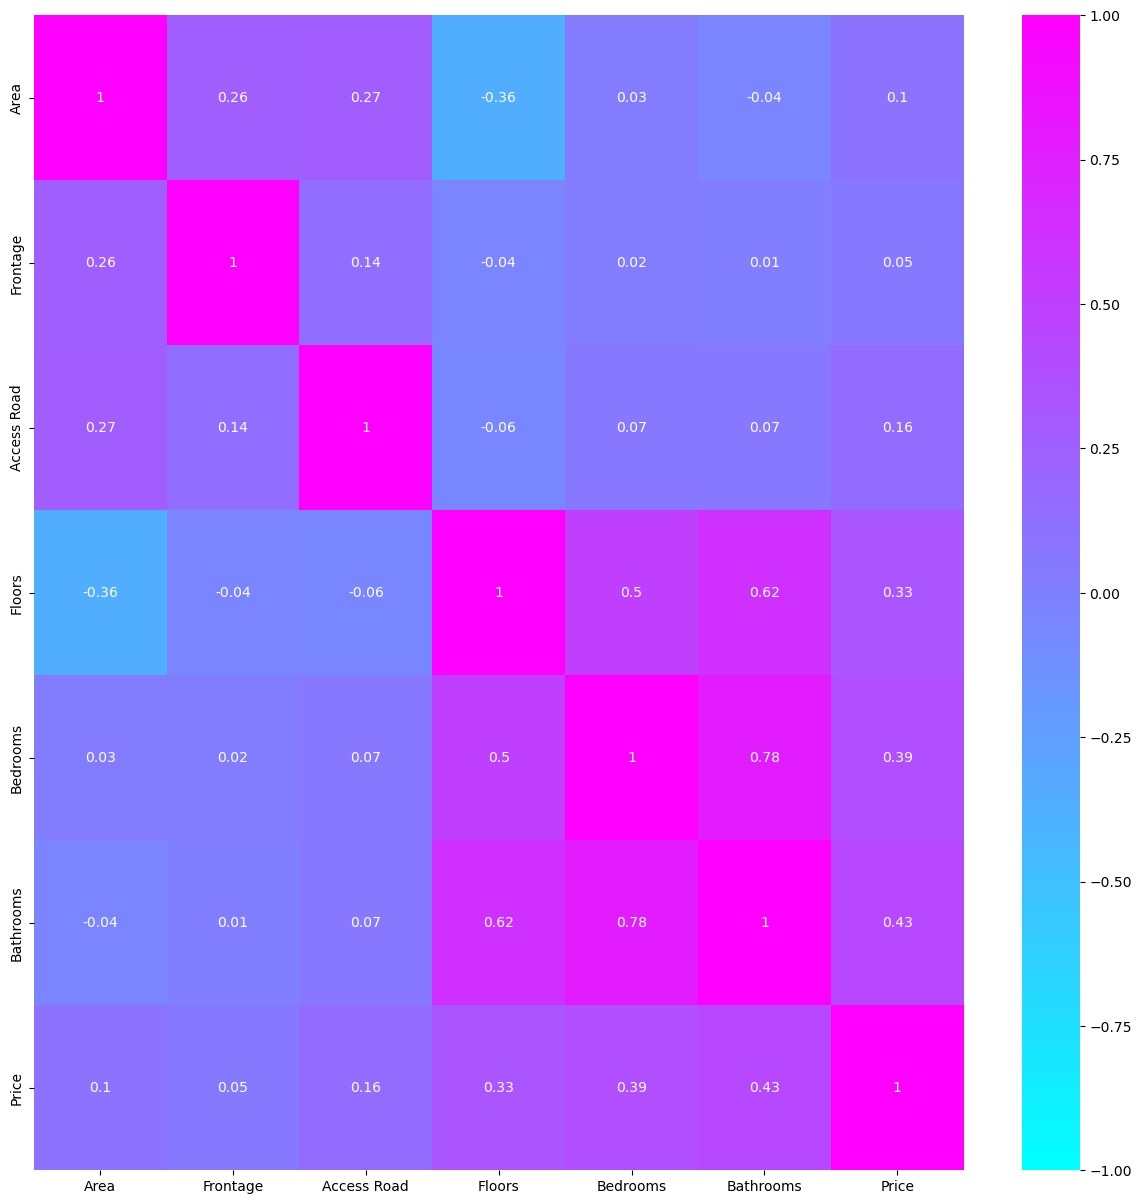

In [74]:
# Hartă de corelare
# Crearea figurii cu dimensiunea 15x15 inch
plt.figure(figsize=(15,15))

# Crearea unui heatmap pentru matricea de corelații 'corr_vietnam'
sns.heatmap(
    data=corr_vietnam,   # datele care vor fi afișate în heatmap
    vmin=-1,            # valoarea minimă a culorilor (pentru scală)
    vmax=1,             # valoarea maximă a culorilor (pentru scală)
    center=0,           # centrul culorilor la 0 (pozitive vs negative)
    annot=True,         # afișează valorile numerice în celule
    cmap='cool'         # paleta de culori folosită
)

# Afișarea graficului
plt.show()


### Interpretare date
Din analiza matricei de corelatie reiese ca variabilele care influenteaza cel mai mult pretul locuintei sunt numarul de bai, numarul de dormitoare si numarul de etaje. Dintre acestea, cea mai puternica legatura cu pretul o are variabila "Bathrooms", cu o corelatie pozitiva moderata de 0.43, urmata de "Bedrooms" (0.39) si "Floors" (0.33), ceea ce sugereaza ca locuintele mai mari, cu mai multe facilitati, tind sa aiba un pret mai ridicat. Celelalte variabile, precum "Area", "Frontage" si "Access Road", prezinta corelatii slabe cu pretul, indicand o influenta redusa asupra valorii totale. In ceea ce priveste relatiile dintre predictorii insisi, se observa o coliniaritate ridicata intre "Bedrooms" si "Bathrooms" (0.78), dar si intre "Bathrooms" si "Floors" (0.62), respectiv "Bedrooms" si "Floors" (0.50).

Bedrooms și Bathrooms au o corelație de 0.78; păstrăm Bathrooms și eliminăm Bedrooms.

In [75]:
cols = ['Bedrooms']
vietnam_nemodificat=vietnam_df
vietnam_df = vietnam_df.drop(columns=cols)

# Verificăm dimensiunea noului dataframe
print("Dimensiunea inițială:", vietnam_nemodificat.shape)
print("Dimensiunea după eliminare:", vietnam_df.shape)

# Verificăm coloanele rămase
print("Coloane rămase:", vietnam_df.columns.tolist())

Dimensiunea inițială: (30229, 12)
Dimensiunea după eliminare: (30229, 11)
Coloane rămase: ['Address', 'Area', 'Frontage', 'Access Road', 'House direction', 'Balcony direction', 'Floors', 'Bathrooms', 'Legal status', 'Furniture state', 'Price']


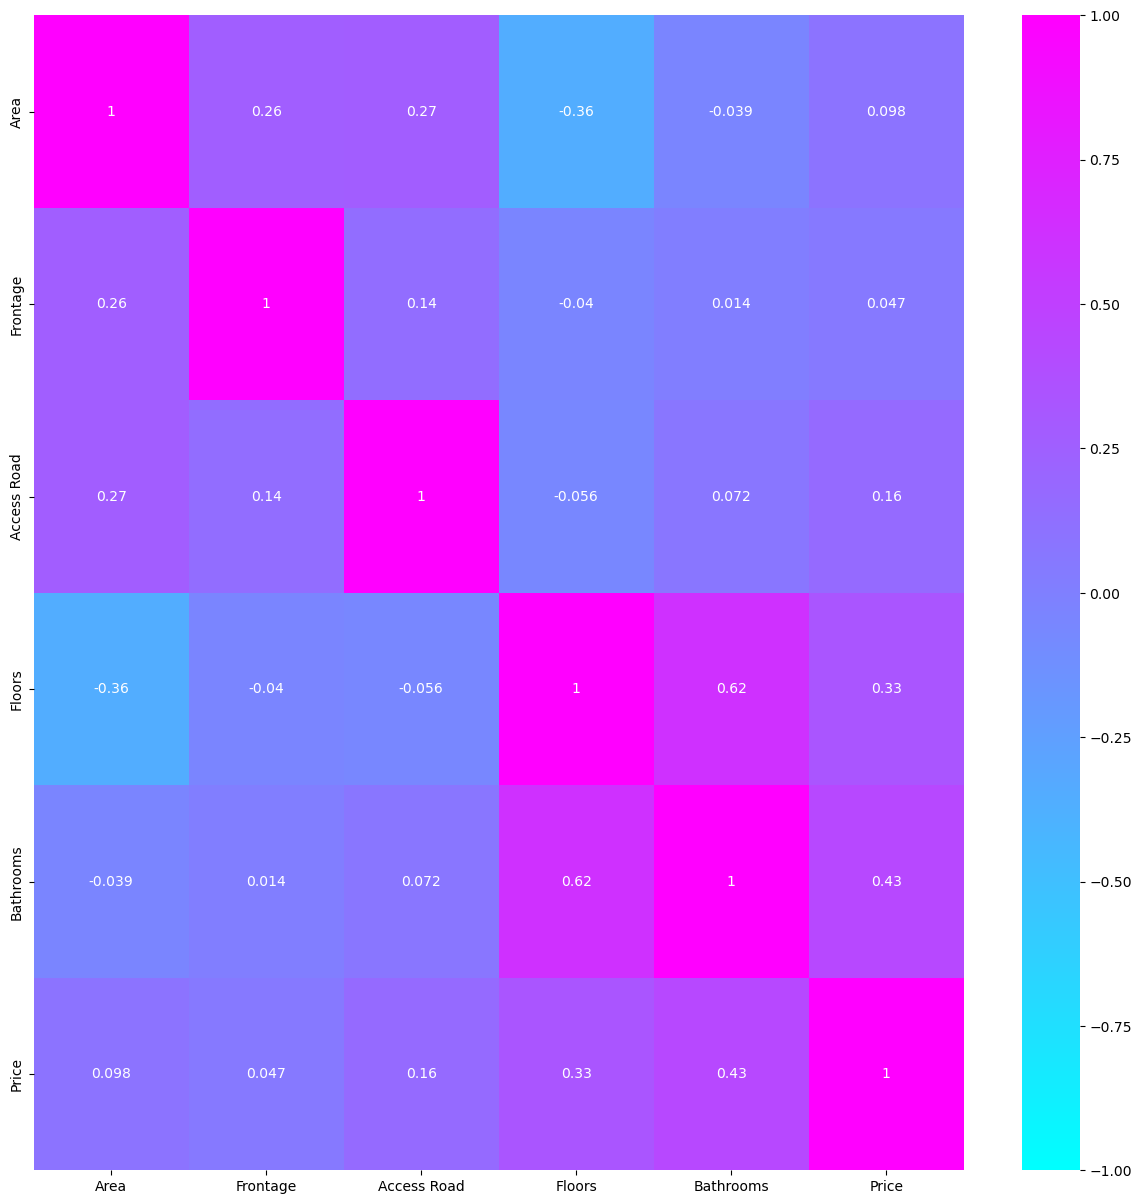

In [76]:
# Hartă de corelare
# Crearea figurii cu dimensiunea 15x15 inch
plt.figure(figsize=(15,15))
corr_vietnam = vietnam_df.corr(numeric_only=True)
# Crearea unui heatmap pentru matricea de corelații 'corr_boston'
sns.heatmap(
    data=corr_vietnam,   # datele care vor fi afișate în heatmap
    vmin=-1,            # valoarea minimă a culorilor (pentru scală)
    vmax=1,             # valoarea maximă a culorilor (pentru scală)
    center=0,           # centrul culorilor la 0 (pozitive vs negative)
    annot=True,         # afișează valorile numerice în celule
    cmap='cool'         # paleta de culori folosită
)

# Afișarea graficului
plt.show()

### Curățarea datelor


In [77]:
print("===== Date lipsă ===== ") 
vietnam_df.isna().sum()

===== Date lipsă ===== 


Address                  0
Area                     0
Frontage             11564
Access Road          13297
House direction      21239
Balcony direction    24983
Floors                3603
Bathrooms             7074
Legal status          4506
Furniture state      14119
Price                    0
dtype: int64

In [78]:
# Eliminăm rândurile cu date lipsă
vietnam_df = vietnam_df.dropna()

In [79]:
# Verificăm că s-a efectuat corect eliminarea
print("===== Date curate ===== ") 
vietnam_df.isna().sum()

===== Date curate ===== 


Address              0
Area                 0
Frontage             0
Access Road          0
House direction      0
Balcony direction    0
Floors               0
Bathrooms            0
Legal status         0
Furniture state      0
Price                0
dtype: int64

In [80]:
# Calcularea Q1, Q3 și IQR pentru Price
Q1 = vietnam_df["Price"].quantile(0.25)
Q3 = vietnam_df["Price"].quantile(0.75)
IQR = Q3 - Q1

# Limitele pentru outlieri
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Limita inferioară:", lower_bound)
print("Limita superioară:", upper_bound)

# Eliminarea outlierilor 
vietnam_df_original= vietnam_df
vietnam_df = vietnam_df[(vietnam_df["Price"] >= lower_bound) & (vietnam_df["Price"] <= upper_bound)]
print("Dimensiune dataset original:", vietnam_df_original.shape)
print("Dimensiune dataset fără outlieri:", vietnam_df.shape)

# Verificarea valorilor pentru siguranță
print("Valori maxime Price după eliminare:", vietnam_df["Price"].max())
print("Valori minime Price după eliminare:", vietnam_df["Price"].min())

Limita inferioară: -1.5850000000000004
Limita superioară: 12.455000000000002
Dimensiune dataset original: (2647, 11)
Dimensiune dataset fără outlieri: (2647, 11)
Valori maxime Price după eliminare: 10.9
Valori minime Price după eliminare: 1.0


In [83]:
# Selectarea coloanelor categorice pentru one-hot encoding
categorical_cols = ['Furniture state', 'Legal status', 'Balcony direction','House direction']

In [86]:
from sklearn.preprocessing import OneHotEncoder

# Crearea encoder-ului
encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' evită colinearitatea

# Aplicarea encoding-ului
encoded = encoder.fit_transform(vietnam_df[categorical_cols])

# Obținerea de nume noi pentru coloane
encoded_cols = encoder.get_feature_names_out(categorical_cols)

# Crearea DataFrame-ului cu coloanele one-hot
df_encoded = pd.DataFrame(encoded, columns=encoded_cols, index=vietnam_df.index)

# Eliminarea coloanelor originale și concatenarea celor one-hot
vietnam_df_modificat = pd.concat([vietnam_df.drop(columns=categorical_cols), df_encoded], axis=1)

vietnam_df_modificat.head()

,Address,Area,Frontage,Access Road,Floors,Bathrooms,Price,Furniture state_Full,Legal status_Sale contract,Balcony direction_Nam,...,Balcony direction_Đông,Balcony direction_Đông - Bắc,Balcony direction_Đông - Nam,House direction_Nam,House direction_Tây,House direction_Tây - Bắc,House direction_Tây - Nam,House direction_Đông,House direction_Đông - Bắc,House direction_Đông - Nam
16,"Dự án Khu đô thị Phương Đông, Xã Đông Xá, Vân ...",300.0,15.0,32.0,3.0,3.0,9.40,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
19,"Đường Quang Trung, Phường 12, Gò Vấp, Hồ Chí Minh",46.0,4.6,6.0,4.0,5.0,7.99,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
23,"Đường Ngô Tất Tố, Phường 22, Bình Thạnh, Hồ Ch...",60.0,3.5,5.0,2.0,5.0,5.60,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
24,"Dự án Vườn Vua Resort & Villas, Đường 316, Xã ...",369.0,15.0,12.0,2.0,4.0,6.30,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
32,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",78.0,6.0,13.0,4.0,6.0,8.63,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [87]:
vietnam_df_modificat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2647 entries, 16 to 30220
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Address                       2647 non-null   object 
 1   Area                          2647 non-null   float64
 2   Frontage                      2647 non-null   float64
 3   Access Road                   2647 non-null   float64
 4   Floors                        2647 non-null   float64
 5   Bathrooms                     2647 non-null   float64
 6   Price                         2647 non-null   float64
 7   Furniture state_Full          2647 non-null   float64
 8   Legal status_Sale contract    2647 non-null   float64
 9   Balcony direction_Nam         2647 non-null   float64
 10  Balcony direction_Tây         2647 non-null   float64
 11  Balcony direction_Tây - Bắc   2647 non-null   float64
 12  Balcony direction_Tây - Nam   2647 non-null   float64
 13  Balcon

# 4 Regresia liniară simplă

In [89]:
# Variabila țintă (valoarea locuinței)
y = vietnam_df_modificat['Price']
y.head()

16    9.40
19    7.99
23    5.60
24    6.30
32    8.63
Name: Price, dtype: float64

In [90]:
# Variabila independentă
X1 = vietnam_df_modificat[['Bathrooms']]
X1.head()

,Bathrooms
16,3.0
19,5.0
23,5.0
24,4.0
32,6.0


In [91]:
# Creare date de antrenare și de testare
from sklearn.model_selection import train_test_split

# Împărțirea datelor în set de antrenare și testare
X1_train, X1_test, y_train, y_test = train_test_split(
    X1, y, test_size=0.2, random_state=42)

print("Dimensiune set antrenare:", X1_train.shape, y_train.shape)
print("Dimensiune set test:", X1_test.shape, y_test.shape)

Dimensiune set antrenare: (2117, 1) (2117,)
Dimensiune set test: (530, 1) (530,)


In [92]:
from sklearn.linear_model import LinearRegression

# Crearea modelului
housing_model1 = LinearRegression()
# Antrenarea modelului pe datele de antrenare
housing_model1.fit(X1_train, y_train)

LinearRegression()

In [93]:
print("Coeficienți:", housing_model1.coef_) 
print("Intercept:", housing_model1.intercept_) #termenul liber din ecuația de regresie.

Coeficienți: [0.77124391]
Intercept: 2.872418818730355


In [95]:
# Prezicerea valorilor pentru setul de test
price_pred1 = housing_model1.predict(X1_test)
r2_1 = housing_model1.score(X1_test, y_test)
print('R-square: %.4f' % r2_1 )

R-square: 0.2271


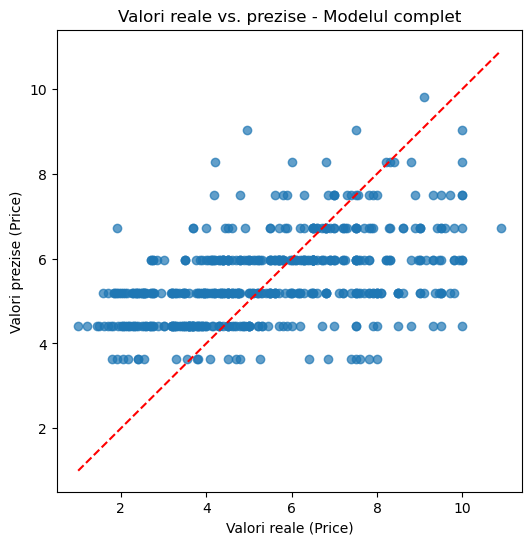

In [97]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, price_pred1, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Valori reale (Price)")
plt.ylabel("Valori prezise (Price)")
plt.title("Valori reale vs. prezise - Modelul complet")
plt.show()

In [98]:
# Evaluarea performanței modelului
from sklearn.metrics import mean_squared_error
import numpy as np

MSE1 = mean_squared_error( y_test, price_pred1)
print("MSE:", MSE1)

RMSE1 = np.sqrt(MSE1)
print("RMSE:", RMSE1)

MSE: 3.696150568695538
RMSE: 1.9225375337546828


Modelul de regresie liniară a obținut un 
 de 0,227, ceea ce înseamnă că explică aproximativ 22,7% din variația prețurilor locuințelor. Eroarea medie pătratică (MSE = 3.7) și abaterea medie (RMSE = 1.92) arată că modelul greșește, în medie, cu aproximativ 1920 de dolari față de valorile reale. Rezultatele indică o performanță moderată, specifică unui model liniar simplu, iar o precizie mai bună ar putea fi obținută prin adăugarea altor variabile.

### 5. Regresia liniară multiplă

In [116]:
# Variabile independente
X2 = vietnam_df_modificat[['Area','Access Road', 'Floors', 'Bathrooms' ]]
X2.head()

,Area,Access Road,Floors,Bathrooms
16,300.0,32.0,3.0,3.0
19,46.0,6.0,4.0,5.0
23,60.0,5.0,2.0,5.0
24,369.0,12.0,2.0,4.0
32,78.0,13.0,4.0,6.0


In [117]:
# Creare date de antrenare și de testare
# Împărțirea datelor în set de antrenare și testare
X2_train, X2_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, random_state=42)

print("Dimensiune set antrenare:", X2_train.shape, y_train.shape)
print("Dimensiune set test:", X2_test.shape, y_test.shape)

Dimensiune set antrenare: (2117, 4) (2117,)
Dimensiune set test: (530, 4) (530,)


In [118]:
# Crearea modelului
housing_model2 = LinearRegression()
# Antrenarea modelului pe datele de antrenare
housing_model2.fit(X2_train, y_train)

LinearRegression()

In [119]:
print("Coeficienți:", housing_model2.coef_) 
print("Intercept:", housing_model2.intercept_)

Coeficienți: [0.00823462 0.04659397 0.26182873 0.60182185]
Intercept: 1.6615050451535138


In [120]:
# Prezicerea valorilor pentru setul de test
price_pred2 = housing_model2.predict(X2_test)
r2_2=housing_model2.score(X2_test, y_test)
print('R-square: %.4f' % r2_2)

R-square: 0.3013


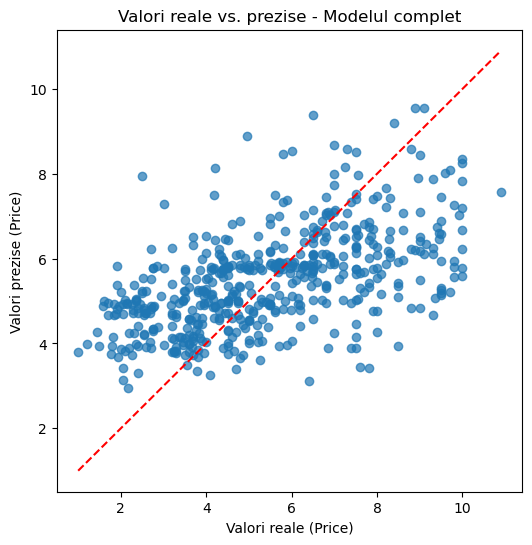

In [122]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, price_pred2, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Valori reale (Price)")
plt.ylabel("Valori prezise (Price)")
plt.title("Valori reale vs. prezise - Modelul complet")
plt.show()


In [123]:
# Evaluarea performanțelor modelului
from sklearn.metrics import mean_squared_error
import numpy as np

MSE2 = mean_squared_error( y_test, price_pred2)
print("MSE:", MSE2)

RMSE2 = np.sqrt(MSE2)
print("RMSE:", RMSE2)

MSE: 3.341364332770042
RMSE: 1.8279399149780724


Modelul de regresie liniară cu patru variabile a obținut un coeficient 
 de 0.301, ceea ce indică faptul că aproximativ 70% din variația prețurilor locuințelor este explicată de variabilele incluse. Eroarea medie pătratică (MSE) are valoarea 3.34, iar abaterea medie (RMSE) este 1.82. Aceste valori arată că modelul are o performanță bună, cu o abatere medie de aproximativ 1820 de dolari față de prețurile reale, ceea ce indică o precizie semnificativ mai bună față de modelul anterior.

In [126]:
# Compararea modelelor 
results = pd.DataFrame({
    "Model": ["Bathrooms", "Area + Access Road + Floors + Bathrooms"],
    "R²": [r2_1, r2_2],
    "RMSE": [RMSE1, RMSE2]
})
print("\nComparație modele:\n", results)


Comparație modele:
                                      Model        R²      RMSE
0                                Bathrooms  0.227094  1.922538
1  Area + Access Road + Floors + Bathrooms  0.301284  1.827940


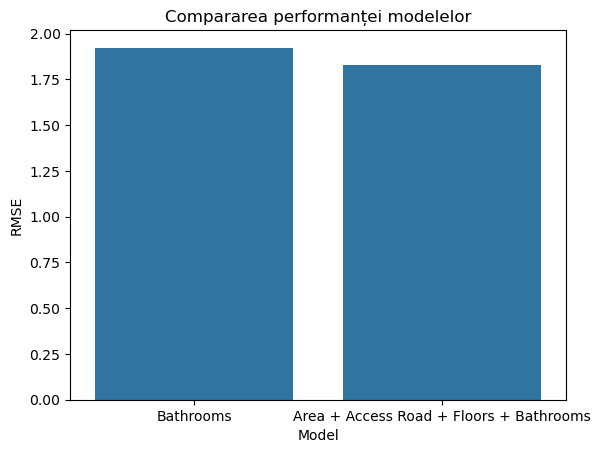

In [127]:
# Vizualizare RMSE 
sns.barplot(x="Model", y="RMSE", data=results)
plt.title("Compararea performanței modelelor")
plt.show()

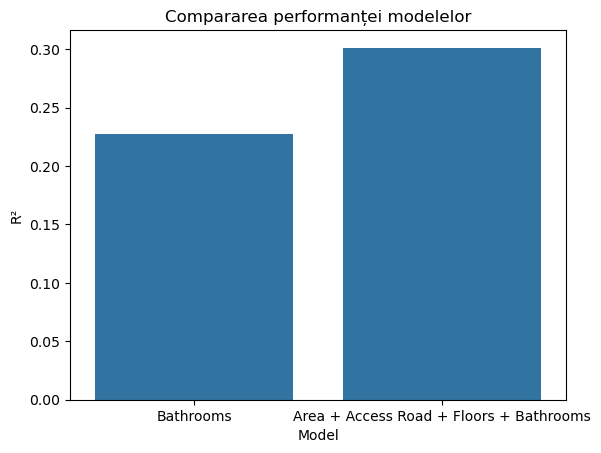

In [128]:
# Vizualizare R² 
sns.barplot(x="Model", y="R²", data=results)
plt.title("Compararea performanței modelelor")
plt.show()

In [ ]:
In concluzie, modelul cu mai multe variabile a fost mai bun, rezultand la o abatere R^2 mai mare si la o eroare RMSE mai mica